In [2]:
special_th = {
    "OOD_1": {
        "sac": [0.5094744861125946, 0.90],
        "sacp": [0.5090510547161102, 0.90],
        "ppo": [0.5684675574302673, 0.80],
        "ppop": [0.6794447898864746, 0.80]  
    },
    "OOD_3": {
        "sac": [0.31788742542266846, 0.90],
        "sacp": [0.30700379610061646, 0.90],
        "ppo": [0.41099679470062256, 0.85],
        "ppop": [0.7184596955776215, 0.85]
    },
    "ST_1": {
        "sac": [0.3536718487739563, 0.95],  
        "sacp": [0.4616701602935791, 0.95],
        "ppo": [0.08668637275695801, 0.80],
        "ppop": [0.22897356748580933, 0.80]
    },
    "ST_2": {
        "sac": [0.12385386228561401, 0.90],
        "sacp": [0.2372249960899353, 0.90],
        "ppo": [0.4210406541824341, 0.90],
        "ppop": [0.6072006821632385, 0.85]
    },
    "SA": {
        "sac": [0.017066597938537598, 0.90],
        "sacp": [0.18005579710006714, 0.90],
        "ppo": [0.12011522054672241, 0.85],
        "ppop": [0.5489180982112885, 0.85]
    }
}

In [3]:
import json, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

In [7]:
def plot_final_uncertainty_distributions(
    df,
    test_order=None,
    policy_order=None,
    bins=50,
    xmax=0.0015,
    density=True,
    figsize=None,
    sharex=True,
    sharey=True,
    savepath=None,
    dpi=300,
    vertical_line=None,
):
 
    import numpy as np
    import matplotlib.pyplot as plt

    plot_df = df.copy()

    plot_df = plot_df.dropna(subset=["unc", "cbf", "test"])

    if test_order is not None:
        plot_df = plot_df[plot_df["test"].isin(test_order)].copy()
        plot_df["test"] = pd.Categorical(
            plot_df["test"],
            categories=test_order,
            ordered=True,
        )

    if policy_order is not None:
        plot_df = plot_df[plot_df["policy"].isin(policy_order)].copy()
        plot_df["policy"] = pd.Categorical(
            plot_df["policy"],
            categories=policy_order,
            ordered=True,
        )

    tests = (
        list(test_order)
        if test_order is not None
        else list(plot_df["test"].dropna().unique())
    )

    tests = [t for t in tests if t in set(plot_df["test"].astype(str))]

    n_tests = len(tests)

    if n_tests == 0:
        raise ValueError("No valid test conditions found for plotting.")

    if figsize is None:
        figsize = (4.2 * n_tests, 3.4)

    fig, axes = plt.subplots(
        1,
        n_tests,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=True,
    )

    if n_tests == 1:
        axes = np.array([axes])

    cbf_labels = {
        0: "CBF constraints satisfied",
        1: "CBF constraints violated",
    }

    test_names = ['90°-turn', 'S-corridor', 'OOD1', 'OOD2', ]
    for i, (ax, test) in enumerate(zip(axes, tests)):
        g = plot_df[plot_df["test"].astype(str) == str(test)]

        for cbf_value in [0, 1]:
            values = g.loc[g["cbf"] == cbf_value, "unc"].dropna()

            if len(values) == 0:
                continue

            ax.hist(
                values,
                bins=bins,
                density=density,
                alpha=0.55,
                label=cbf_labels[cbf_value],
                edgecolor="black",
                linewidth=0.25,
            )

            if vertical_line is not None:
                ax.axvline(
                    vertical_line,
                    color="red",
                    linestyle="--",
                    linewidth=1.5,
                )
                
        ax.set_title(f"{test_names[i]}", fontsize=11)
        ax.set_xlabel("Estimated Epistemic uncertainty", fontsize=10)

        if xmax is not None:
            ax.set_xlim(right=xmax)
            
        ax.grid(axis="y", alpha=0.25)

    axes[0].set_ylabel(
        "Density" if density else "Number of transitions",
        fontsize=10,
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.08),
    )

    fig.suptitle(
        f'{plot_df["policy"].iloc[0].upper()}',
        fontsize=13,
        y=1.14,
    )

    for ax in axes:
        ax.tick_params(axis="both", labelsize=9)

    if savepath is not None:
        fig.savefig(
            savepath,
            dpi=dpi,
            bbox_inches="tight",
        )

    return fig, axes

In [ ]:
def analyze_stats(
    path="./stats.json",
    test_order=["ST_1", "ST_2", "SA", "OOD_1", "OOD_3"],
    policy_order=["sac", "sacp", "ppo", "ppop"],
    special_th=None,
    threshold_idx=0,
    plot=0,
    vertical_line=None,
):
    """
    Se special_th è None:
        usa le vere attivazioni UF presenti nel file.

    Se special_th è un dizionario:
        special_th[test][policy] = [threshold_0, threshold_1]

    allora:
        sceglie threshold = special_th[test][policy][threshold_idx]
        ignora completamente le vere UF
        calcola metriche attese analiticamente assumendo:

            activation_prob = 1 - threshold

        Nessun Monte Carlo viene usato.
    """

    path = str(path)

    with (
        gzip.open(path, "rt", encoding="utf-8")
        if path.endswith(".gz")
        else open(path, "r", encoding="utf-8")
    ) as f:
        stats = json.load(f)

    data = stats["data"] if isinstance(stats, dict) and "data" in stats else stats

    rows = []

    for test, policies in data.items():
        if test == "SA":
            continue
        for policy, episodes in policies.items():
            for ep_i, ep in enumerate(episodes):
                for tr_i, x in enumerate(ep):

                    if isinstance(x, dict):
                        uf_true = int(x["uf_activation"])
                        cbf = int(x["cbf_activation"])
                        unc = (
                            float(x["epistemic_unc"])
                            if x["epistemic_unc"] is not None
                            else np.nan
                        )
                    else:
                        uf_true = int(x[0])
                        cbf = int(x[1])
                        unc = float(x[2]) if x[2] is not None else np.nan

                    if special_th is not None:
                        try:
                            threshold = float(special_th[test][policy][threshold_idx])
                        except KeyError as e:
                            raise KeyError(
                                f"special_th non contiene la coppia test/policy: "
                                f"test={test}, policy={policy}"
                            ) from e
                        except IndexError as e:
                            raise IndexError(
                                f"threshold_idx={threshold_idx} non valido per "
                                f"special_th[{test!r}][{policy!r}] = "
                                f"{special_th[test][policy]}"
                            ) from e

                        if not (0.0 <= threshold <= 1.0):
                            raise ValueError(
                                f"threshold deve essere in [0, 1], ma per "
                                f"test={test}, policy={policy} vale {threshold}"
                            )

                        activation_prob = 1.0 - threshold
                    else:
                        threshold = np.nan
                        activation_prob = np.nan

                    rows.append(
                        (
                            test,
                            policy,
                            ep_i,
                            tr_i,
                            uf_true,
                            cbf,
                            unc,
                            threshold,
                            activation_prob,
                        )
                    )

    df = pd.DataFrame(
        rows,
        columns=[
            "test",
            "policy",
            "episode",
            "transition",
            "uf_true",
            "cbf",
            "unc",
            "threshold",
            "activation_prob",
        ],
    )

    if test_order is not None:
        df = df[df["test"].isin(test_order)].copy()
        df["test"] = pd.Categorical(
            df["test"],
            categories=test_order,
            ordered=True,
        )

    if policy_order is not None:
        df = df[df["policy"].isin(policy_order)].copy()
        df["policy"] = pd.Categorical(
            df["policy"],
            categories=policy_order,
            ordered=True,
        )

    def wilson_ci(successes, n, confidence=0.95):
        """
        Wilson score interval per una proporzione binomiale.

        successes: numero di successi, qui FP
        n: numero di prove, qui TP + FP
        """
        if n == 0:
            return np.nan, np.nan

        z = 1.959963984540054  # 95%

        phat = successes / n
        denom = 1.0 + z**2 / n

        center = (phat + z**2 / (2.0 * n)) / denom
        half_width = (
            z
            * np.sqrt((phat * (1.0 - phat) / n) + (z**2 / (4.0 * n**2)))
            / denom
        )

        return center - half_width, center + half_width

    def metrics(g):
        y = g["cbf"].to_numpy()

        if special_th is None:
            p = g["uf_true"].to_numpy()

            tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel()

            precision = precision_score(y, p, zero_division=0)
            recall = recall_score(y, p, zero_division=0)
            f1 = f1_score(y, p, zero_division=0)
            acc = accuracy_score(y, p)

            fa_n = tp + fp
            fa_rate = fp / fa_n if fa_n else np.nan
            fa_wilson_low, fa_wilson_high = wilson_ci(fp, fa_n)
            
            uf_percent = 100 * p.mean()

            threshold = np.nan
            activation_prob = np.nan

        else:
            threshold = g["threshold"].iloc[0]
            activation_prob = g["activation_prob"].iloc[0]

            q = activation_prob

            positives = np.sum(y == 1)
            negatives = np.sum(y == 0)

            tp = q * positives
            fn = (1.0 - q) * positives
            fp = q * negatives
            tn = (1.0 - q) * negatives

            fa_n = tp + fp
            fa_rate = (fp / fa_n) if fa_n else np.nan
            fa_wilson_low, fa_wilson_high = wilson_ci(fp, fa_n)

            total = positives + negatives

            acc = (tp + tn) / total if total else np.nan

            precision = tp / (tp + fp) if (tp + fp) else 0.0
            recall = tp / (tp + fn) if (tp + fn) else 0.0
            f1 = (
                2 * precision * recall / (precision + recall)
                if (precision + recall)
                else 0.0
            )

            uf_percent = 100 * q

        return pd.Series({
            "n": len(g),

            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,

            "acc": acc,
            "prec": precision,
            "recall": recall,
            "f1": f1,

            "FPR": fp / (fp + tn) if (fp + tn) else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) else np.nan,

            "fa_rate": fa_rate * 100,
            "fa_rate_wilson_low": (fa_wilson_low - fa_rate) * 100,
            "fa_rate_wilson_high": (fa_wilson_high - fa_rate) * 100,

            #"UF%": uf_percent,
            #"CBF%": 100 * y.mean(),

            #"UF_true%": 100 * g["uf_true"].mean(),
        })

    summary = (
        df
        .groupby(["test", "policy"], observed=True)
        .apply(metrics)
        .reset_index()
    )

    numeric_cols = summary.select_dtypes(include="number").columns

    mean_row = {}
    for col in summary.columns:
        if col == "test":
            mean_row[col] = "MEAN"
        elif col == "policy":
            mean_row[col] = "ALL"
        elif col in numeric_cols:
            mean_row[col] = summary[col].mean()
        else:
            mean_row[col] = np.nan

    summary = pd.concat(
        [summary, pd.DataFrame([mean_row])],
        ignore_index=True,
    )

    if plot == 1:
        for (test, policy), g in df.groupby(["test", "policy"], observed=True):
            fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

            ax[0].hist(g["unc"].dropna(), bins=50)
            ax[0].set_title(f"{test} | {policy}\nuncertainty")
            ax[0].set_xlabel("epistemic_unc")
            ax[0].set_ylabel("count")

            ax[1].hist(
                g.loc[g.cbf == 0, "unc"].dropna(),
                bins=50,
                alpha=0.6,
                label="CBF=0",
            )
            ax[1].hist(
                g.loc[g.cbf == 1, "unc"].dropna(),
                bins=50,
                alpha=0.6,
                label="CBF=1",
            )
            ax[1].set_title("uncertainty by true label")
            ax[1].set_xlabel("epistemic_unc")
            ax[1].legend()

            plt.tight_layout()
            plt.show()
    elif plot > 1:
        plot_final_uncertainty_distributions(
            df,
            test_order=test_order,
            policy_order=policy_order,
            bins=50,
            density=True,
            savepath=None,
            vertical_line=vertical_line,
        )
    return summary


# PPO

In [5]:
analyze_stats('./results_stats/stats_ext_ppo.json', 
    plot=False,
    special_th=special_th,
)


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\4228994186.py:294: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


,test,policy,n,TP,FP,TN,FN,acc,acc_CI_low,acc_CI_high,...,fa_rate_CI_high,UF%,UF%_CI_low,UF%_CI_high,CBF%,CBF%_CI_low,CBF%_CI_high,UF_true%,UF_true%_CI_low,UF_true%_CI_high
0,OOD_1,ppo,138504.00,31472.092569,28296.876857,37276.123143,41458.907431,0.496363,0.493730,0.498996,...,0.477442,43.153244,42.892596,43.414272,52.656241,52.393221,52.919114,43.028360,42.767807,43.289300
1,OOD_3,ppo,131932.00,36172.453847,41535.917035,28983.082965,25240.546153,0.493857,0.491159,0.496555,...,0.538016,58.900321,58.634573,59.165549,46.548980,46.279927,46.818234,58.634751,58.368757,58.900243
2,ST_1,ppo,180351.00,108866.984367,55850.041620,5300.958380,10333.015633,0.633032,0.630805,0.635253,...,0.341356,91.331363,91.200621,91.460344,66.093340,65.874520,66.311475,91.558128,91.428933,91.685554
3,ST_2,ppo,125626.00,52700.932372,20031.414406,14567.585594,38326.067628,0.535467,0.532708,0.538223,...,0.278671,57.895935,57.622677,58.168709,72.458727,72.211015,72.705065,58.015061,57.741906,58.287725
4,MEAN,ALL,144103.25,57303.115789,36428.562479,21531.937521,28839.634211,0.539680,0.537100,0.542257,...,0.408871,62.820216,62.587617,63.052219,59.439322,59.189671,59.688472,62.809075,62.576851,63.040705


In [18]:
analyze_stats('./results_stats/stats_ppo.json', 
    plot=False
)

C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\4228994186.py:294: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


,test,policy,n,TP,FP,TN,FN,acc,acc_CI_low,acc_CI_high,...,fa_rate_CI_high,UF%,UF%_CI_low,UF%_CI_high,CBF%,CBF%_CI_low,CBF%_CI_high,UF_true%,UF_true%_CI_low,UF_true%_CI_high
0,OOD_1,ppo,14617.00,3580.00,1819.00,4272.00,4946.0,0.537183,0.529091,0.545255,...,0.349634,36.936444,36.157559,37.722193,58.329343,57.528015,59.126293,36.936444,36.157559,37.722193
1,OOD_3,ppo,11939.00,4062.00,2514.00,4271.00,1092.0,0.697965,0.689666,0.706136,...,0.394110,55.079990,54.186259,55.970452,43.169445,42.283311,44.059973,55.079990,54.186259,55.970452
2,ST_1,ppo,34701.00,20414.00,10166.00,2018.00,2103.0,0.646437,0.641391,0.651450,...,0.337740,88.124262,87.779661,88.460422,64.888620,64.384787,65.389157,88.124262,87.779661,88.460422
3,ST_2,ppo,26528.00,10303.00,4412.00,3392.00,8421.0,0.516247,0.510231,0.522258,...,0.307285,55.469692,54.870874,56.066927,70.582027,70.030739,71.127354,55.469692,54.870874,56.066927
4,MEAN,ALL,21946.25,9589.75,4727.75,3488.25,4140.5,0.599458,0.592595,0.606275,...,0.347192,58.902597,58.248588,59.554999,59.242358,58.556713,59.925694,58.902597,58.248588,59.554999


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\4228994186.py:294: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


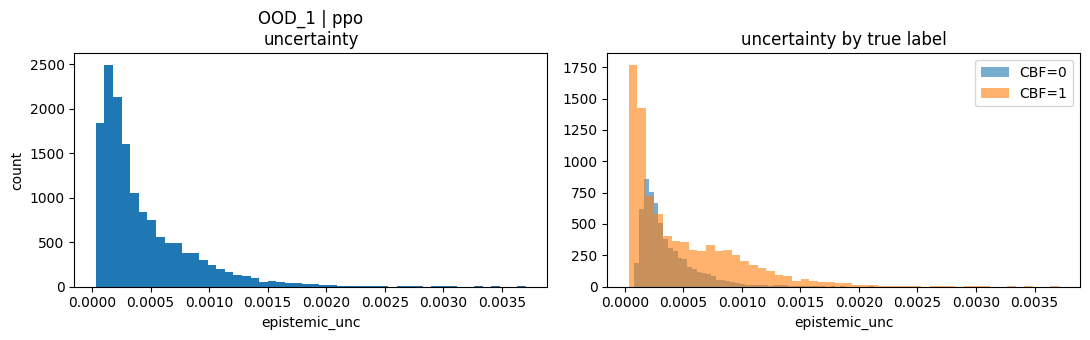

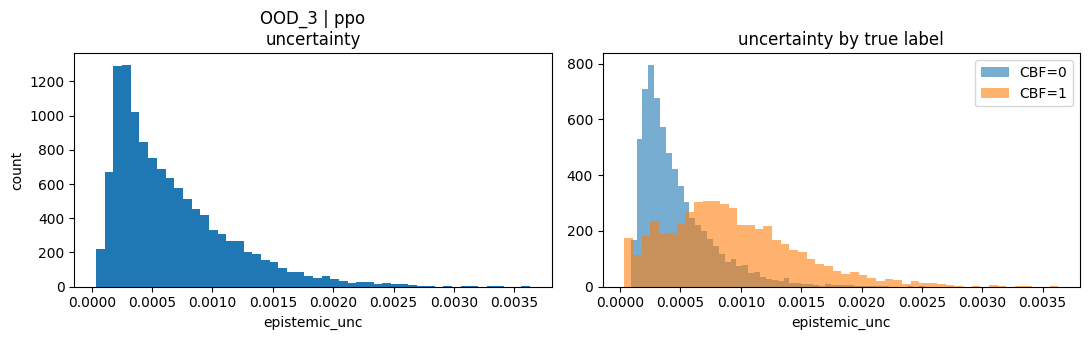

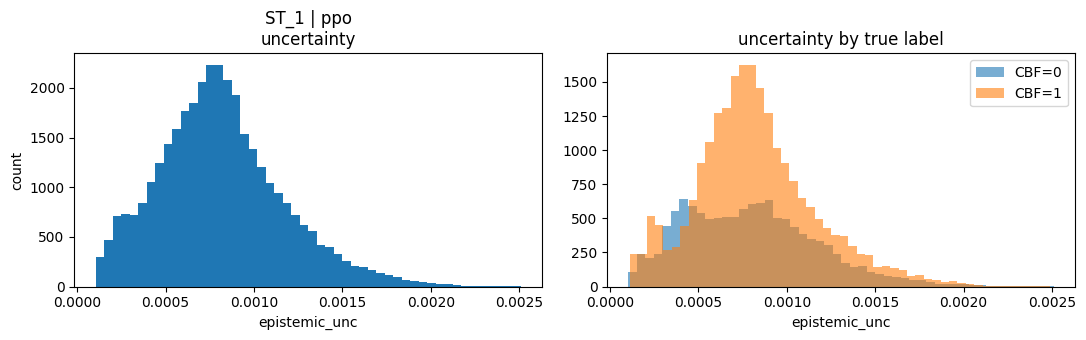

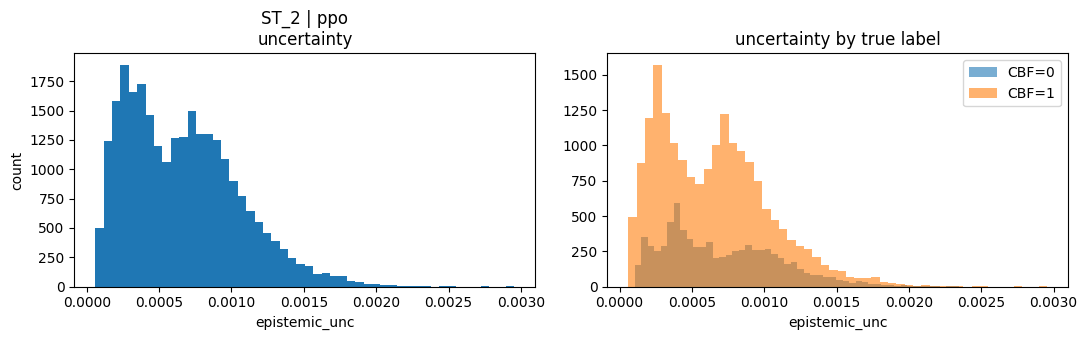

In [7]:
analyze_stats('./results_stats/stats_ppo.json', 
    plot=1
);


# PPOP

In [8]:
analyze_stats('./results_stats/stats_ext_ppop.json', 
    plot=False,
    special_th=special_th,
)


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\4228994186.py:294: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


,test,policy,n,TP,FP,TN,FN,acc,acc_CI_low,acc_CI_high,...,fa_rate_CI_high,UF%,UF%_CI_low,UF%_CI_high,CBF%,CBF%_CI_low,CBF%_CI_high,UF_true%,UF_true%_CI_low,UF_true%_CI_high
0,OOD_1,ppop,130564.00,22323.464832,19529.505621,41394.494379,47316.535168,0.488021,0.485310,0.490733,...,0.471404,32.055521,31.802910,32.309188,53.337827,53.067127,53.608330,32.302932,32.049801,32.557104
1,OOD_3,ppop,106239.00,12960.426374,16950.134028,43254.865972,33073.573626,0.529140,0.526137,0.532140,...,0.572301,28.154030,27.884380,28.425261,43.330604,43.032876,43.628813,27.779817,27.511285,28.049956
2,ST_1,ppop,165393.00,87940.961813,39581.412940,11754.587060,26116.038187,0.602780,0.600419,0.605136,...,0.312933,77.102643,76.899519,77.304509,68.961202,68.737794,69.183728,77.162879,76.959941,77.364555
3,ST_2,ppop,122183.00,34857.404264,13135.994787,20306.005213,53883.595736,0.451482,0.448693,0.454274,...,0.277711,39.279932,39.006435,39.554103,72.629580,72.378872,72.878866,38.739432,38.466634,39.012937
4,MEAN,ALL,131094.75,39520.564321,22299.261844,29177.488156,40097.435679,0.517856,0.515140,0.520571,...,0.408587,44.148032,43.898311,44.398265,59.564803,59.304167,59.824934,43.996265,43.746915,44.246138


In [9]:
analyze_stats('./results_stats/stats_ext_ppop.json', 
    plot=False,
)


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\4228994186.py:294: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


,test,policy,n,TP,FP,TN,FN,acc,acc_CI_low,acc_CI_high,...,fa_rate_CI_high,UF%,UF%_CI_low,UF%_CI_high,CBF%,CBF%_CI_low,CBF%_CI_high,UF_true%,UF_true%_CI_low,UF_true%_CI_high
0,OOD_1,ppop,130564.00,28248.0,13928.0,46996.00,41392.0,0.576300,0.573617,0.578978,...,0.334739,32.302932,32.049801,32.557104,53.337827,53.067127,53.608330,32.302932,32.049801,32.557104
1,OOD_3,ppop,106239.00,17537.0,11976.0,48229.00,28497.0,0.619038,0.616114,0.621954,...,0.411401,27.779817,27.511285,28.049956,43.330604,43.032876,43.628813,27.779817,27.511285,28.049956
2,ST_1,ppop,165393.00,91699.0,35923.0,15413.00,22358.0,0.647621,0.645315,0.649920,...,0.283954,77.162879,76.959941,77.364555,68.961202,68.737794,69.183728,77.162879,76.959941,77.364555
3,ST_2,ppop,122183.00,35664.0,11669.0,21773.00,53077.0,0.470090,0.467292,0.472889,...,0.250433,38.739432,38.466634,39.012937,72.629580,72.378872,72.878866,38.739432,38.466634,39.012937
4,MEAN,ALL,131094.75,43287.0,18374.0,33102.75,36331.0,0.578262,0.575585,0.580935,...,0.320132,43.996265,43.746915,44.246138,59.564803,59.304167,59.824934,43.996265,43.746915,44.246138


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\4228994186.py:294: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


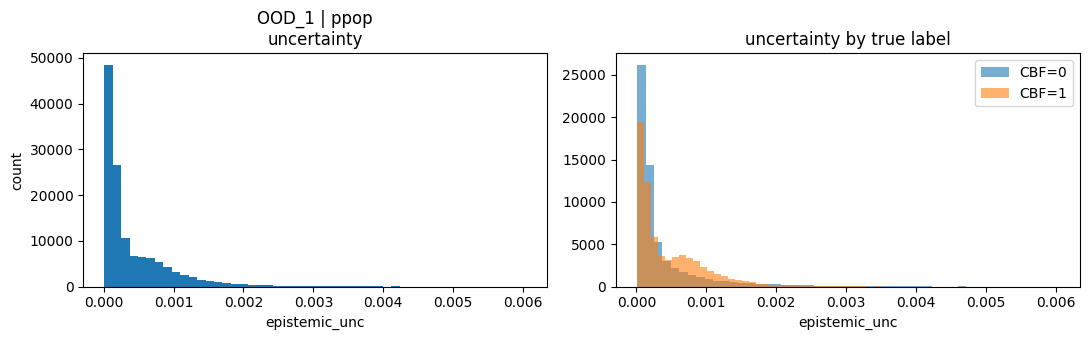

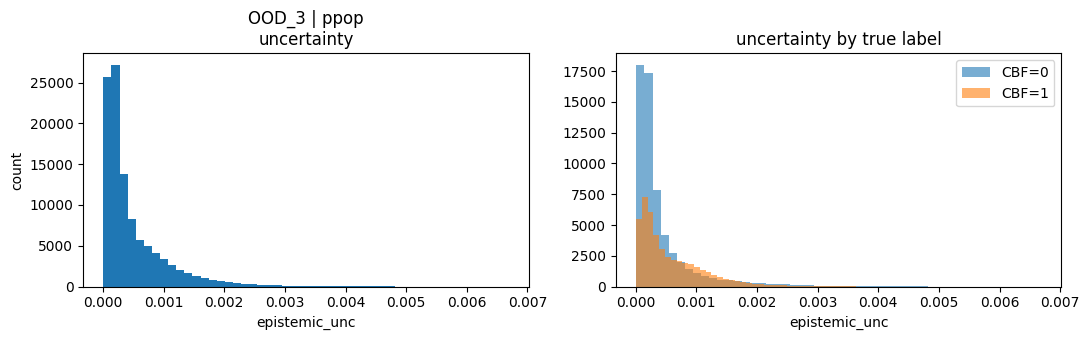

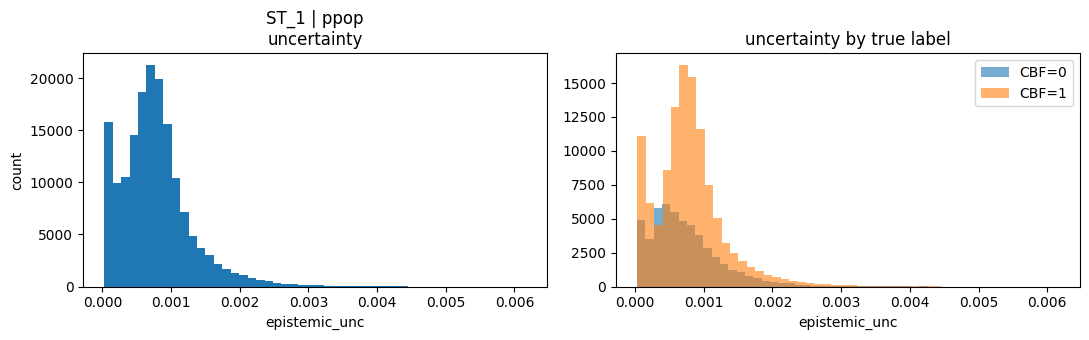

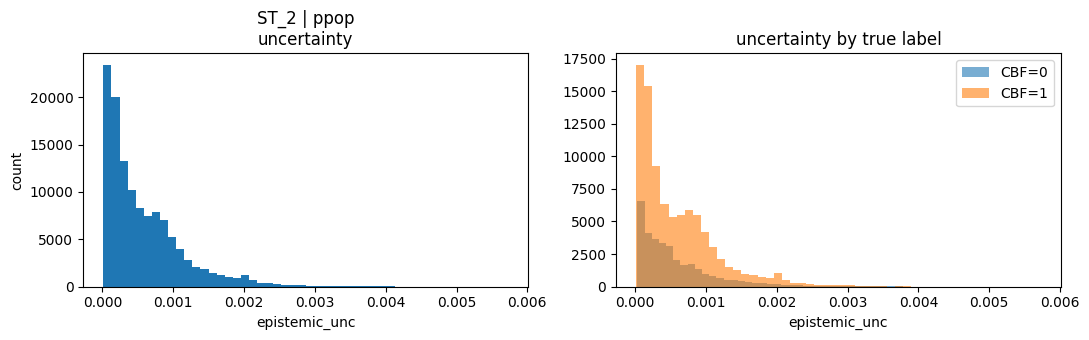

In [10]:
analyze_stats('./results_stats/stats_ext_ppop.json', 
    plot=1,
);


# SAC

In [34]:
analyze_stats('./results_stats/stats_ext_sac.json', 
    plot=False,
    special_th=special_th,
)

C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\3416708179.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


,test,policy,n,TP,FP,TN,FN,acc,prec,recall,f1,FPR,FNR,fa_rate,fa_rate_wilson_low,fa_rate_wilson_high
0,OOD_1,sac,125708.00,31573.655752,30089.325547,31251.674453,32793.344248,0.499772,0.512036,0.490526,0.501050,0.490526,0.509474,48.796417,-0.394443,0.394593
1,OOD_3,sac,130805.00,41111.606982,48112.128335,22421.871665,19159.393018,0.485711,0.460770,0.682113,0.550007,0.682113,0.317887,53.923015,-0.327229,0.326891
2,ST_1,sac,63967.00,34307.744595,7035.928254,3850.071746,18773.255405,0.596523,0.829819,0.646328,0.726669,0.646328,0.353672,17.018150,-0.359168,0.365296
3,ST_2,sac,77439.00,57671.443369,10176.437390,1438.562610,8152.556631,0.763311,0.850011,0.876146,0.862881,0.876146,0.123854,14.998902,-0.266690,0.270653
4,MEAN,ALL,99479.75,41166.112675,23853.454882,14740.545118,19719.637325,0.586329,0.663159,0.673778,0.660152,0.673778,0.326222,33.684121,-0.336882,0.339358


In [36]:
analyze_stats('./results_stats/stats_ext_sac.json', 
    plot=False,
)

C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\3416708179.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


,test,policy,n,TP,FP,TN,FN,acc,prec,recall,f1,FPR,FNR,fa_rate,fa_rate_wilson_low,fa_rate_wilson_high
0,OOD_1,sac,125708.00,53584.0,10221.0,51120.0,10783.00,0.832914,0.839809,0.832476,0.836126,0.166626,0.167524,16.019121,-0.282550,0.286641
1,OOD_3,sac,130805.00,57180.0,31466.0,39068.0,3091.00,0.735813,0.645038,0.948715,0.767945,0.446111,0.051285,35.496243,-0.314359,0.315616
2,ST_1,sac,63967.00,36810.0,4693.0,6193.0,16271.00,0.672269,0.886924,0.693468,0.778356,0.431104,0.306532,11.307616,-0.301101,0.308263
3,ST_2,sac,77439.00,62502.0,5472.0,6143.0,3322.00,0.886440,0.919499,0.949532,0.934274,0.471115,0.050468,8.050137,-0.202166,0.206907
4,MEAN,ALL,99479.75,52519.0,12963.0,25631.0,8366.75,0.781859,0.822817,0.856048,0.829175,0.378739,0.143952,17.718279,-0.275044,0.279357


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\3416708179.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


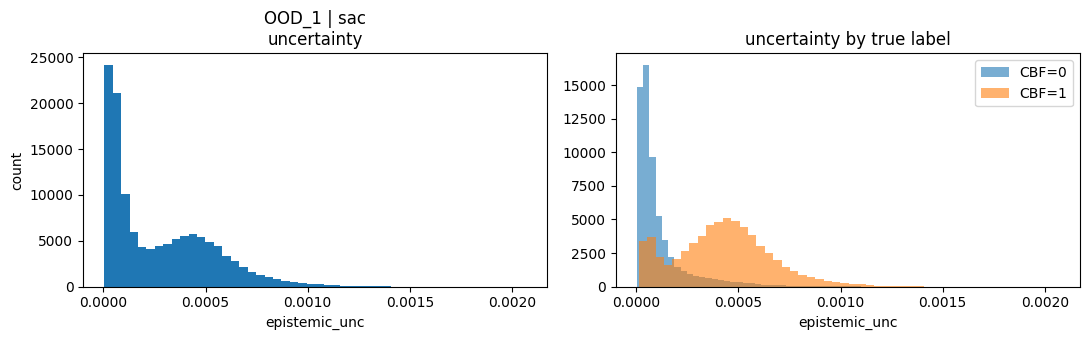

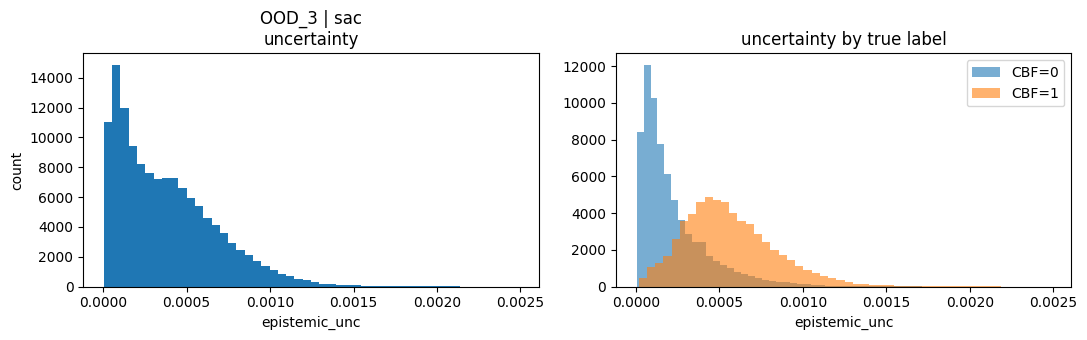

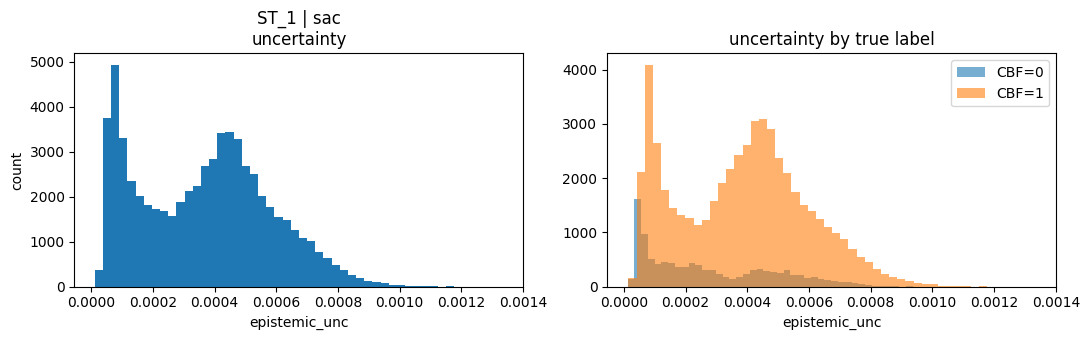

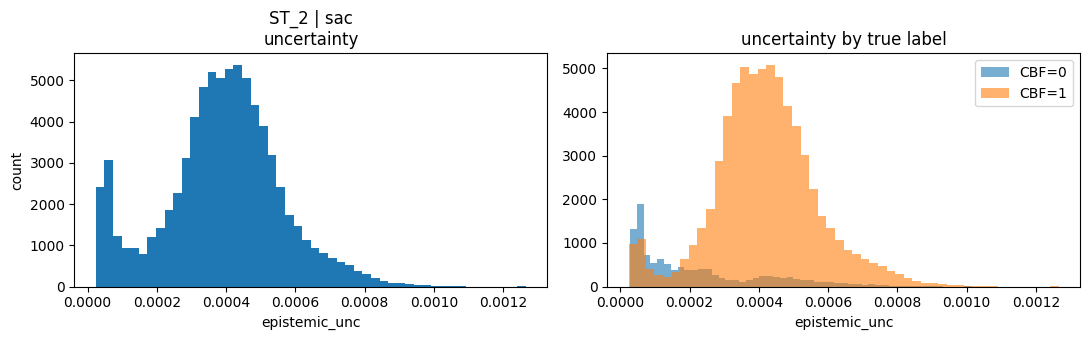

In [35]:
analyze_stats('./results_stats/stats_ext_sac.json', 
    plot=True,
);


# SACP

In [47]:
analyze_stats('./results_stats/stats_ext_sacp.json', 
    plot=False,
    special_th=special_th,
)


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\3416708179.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


,test,policy,n,TP,FP,TN,FN,acc,prec,recall,f1,FPR,FNR,fa_rate,fa_rate_wilson_low,fa_rate_wilson_high
0,OOD_1,sacp,122053.00,32214.596943,27707.194676,28728.805324,33402.403057,0.499319,0.537611,0.490949,0.513221,0.490949,0.509051,46.238929,-0.398949,0.399431
1,OOD_3,sacp,127358.00,42614.415566,45644.194970,20220.805030,18878.584434,0.493375,0.482836,0.692996,0.569135,0.692996,0.307004,51.716421,-0.329741,0.329591
2,ST_1,sacp,65588.00,30145.394364,5162.583163,4427.416837,25852.605636,0.527121,0.853784,0.538330,0.660316,0.538330,0.461670,14.621577,-0.364690,0.372387
3,ST_2,sacp,75576.00,49227.210427,8420.273268,2618.726732,15309.789573,0.686011,0.853935,0.762775,0.805785,0.762775,0.237225,14.606489,-0.285941,0.290657
4,MEAN,ALL,97643.75,38550.404325,21733.561519,13998.938481,23360.845675,0.551456,0.682041,0.621262,0.637114,0.621262,0.378738,31.795854,-0.344830,0.348017


In [48]:
analyze_stats('./results_stats/stats_ext_sacp.json', 
    plot=False,
)


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\3416708179.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


,test,policy,n,TP,FP,TN,FN,acc,prec,recall,f1,FPR,FNR,fa_rate,fa_rate_wilson_low,fa_rate_wilson_high
0,OOD_1,sacp,122053.00,46169.0,12339.0,44097.0,19448.00,0.739564,0.789106,0.703613,0.743911,0.218637,0.296387,21.089424,-0.328649,0.332445
1,OOD_3,sacp,127358.00,58227.0,30949.0,34916.0,3266.00,0.731348,0.652945,0.946888,0.772913,0.469885,0.053112,34.705526,-0.311772,0.313089
2,ST_1,sacp,65588.00,30500.0,5003.0,4587.0,25498.00,0.534961,0.859082,0.544662,0.666659,0.521689,0.455338,14.091767,-0.358039,0.365809
3,ST_2,sacp,75576.00,49472.0,8323.0,2716.0,15065.00,0.690537,0.855991,0.766568,0.808815,0.753963,0.233432,14.400900,-0.283876,0.288608
4,MEAN,ALL,97643.75,46092.0,14153.5,21579.0,15819.25,0.674102,0.789281,0.740433,0.748075,0.491044,0.259567,21.071904,-0.320584,0.324988


C:\Users\cicci\AppData\Local\Temp\ipykernel_19280\4228994186.py:294: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


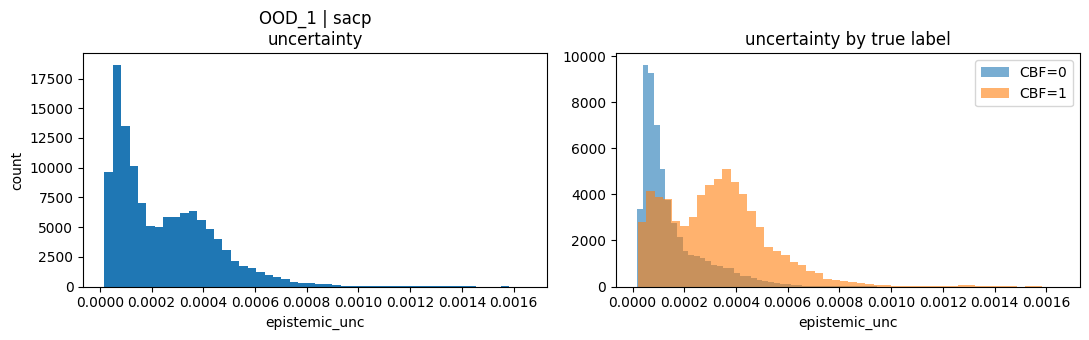

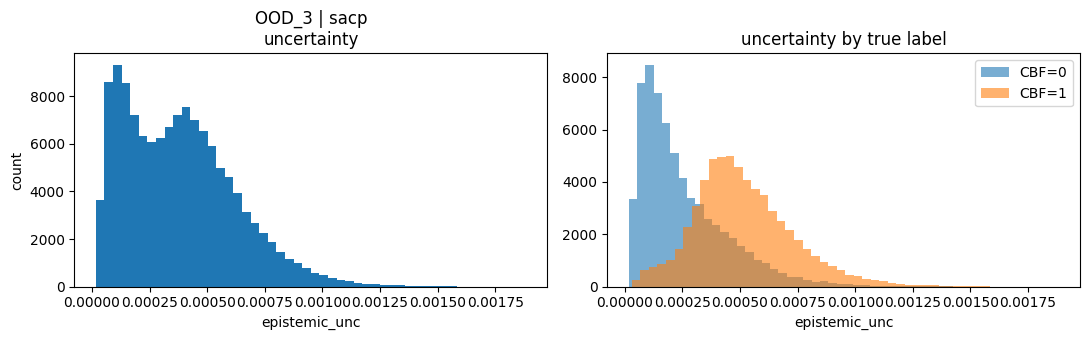

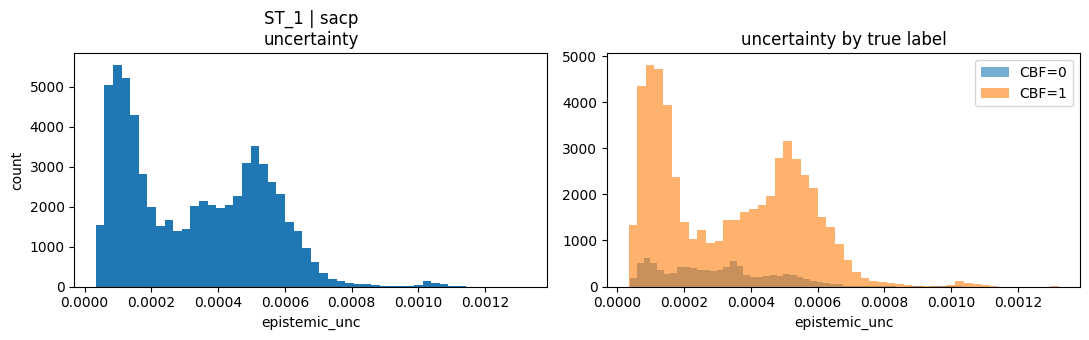

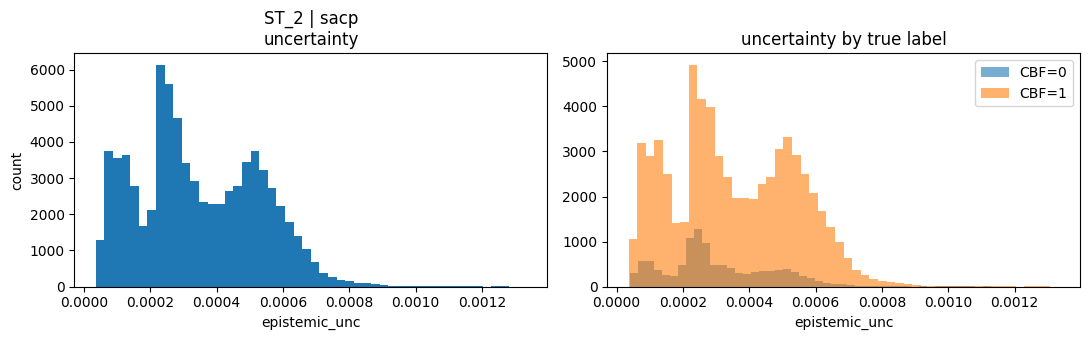

In [16]:
analyze_stats('./results_stats/stats_ext_sacp.json', 
    plot=True,
);


# Paper Plot e tab

C:\Users\cicci\AppData\Local\Temp\ipykernel_2140\3660049042.py:238: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)
C:\Users\cicci\AppData\Local\Temp\ipykernel_2140\3660049042.py:238: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metrics)


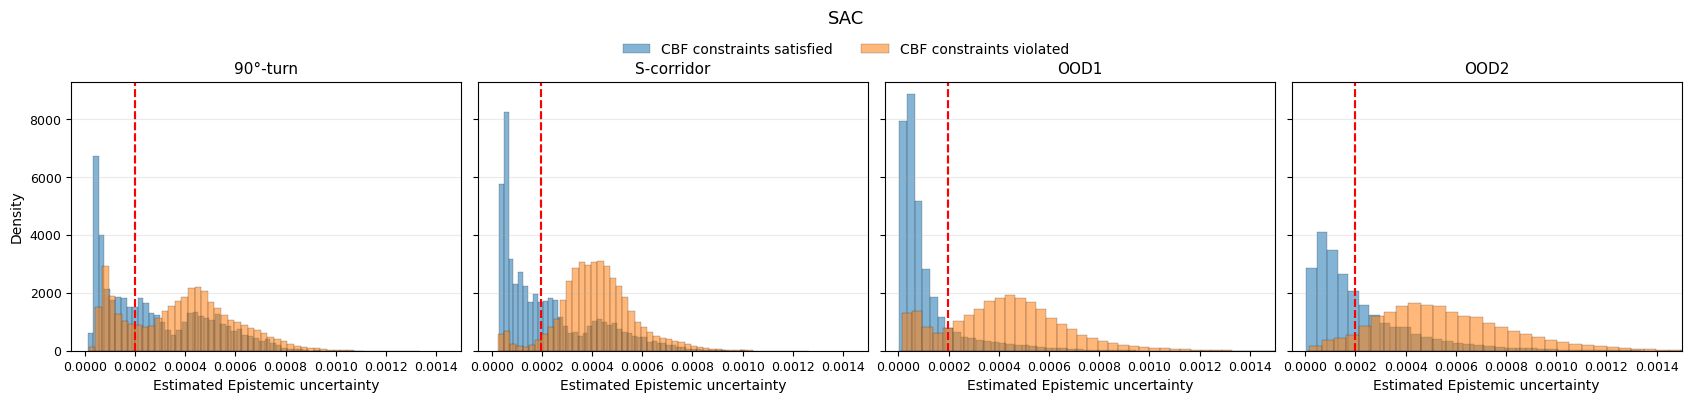

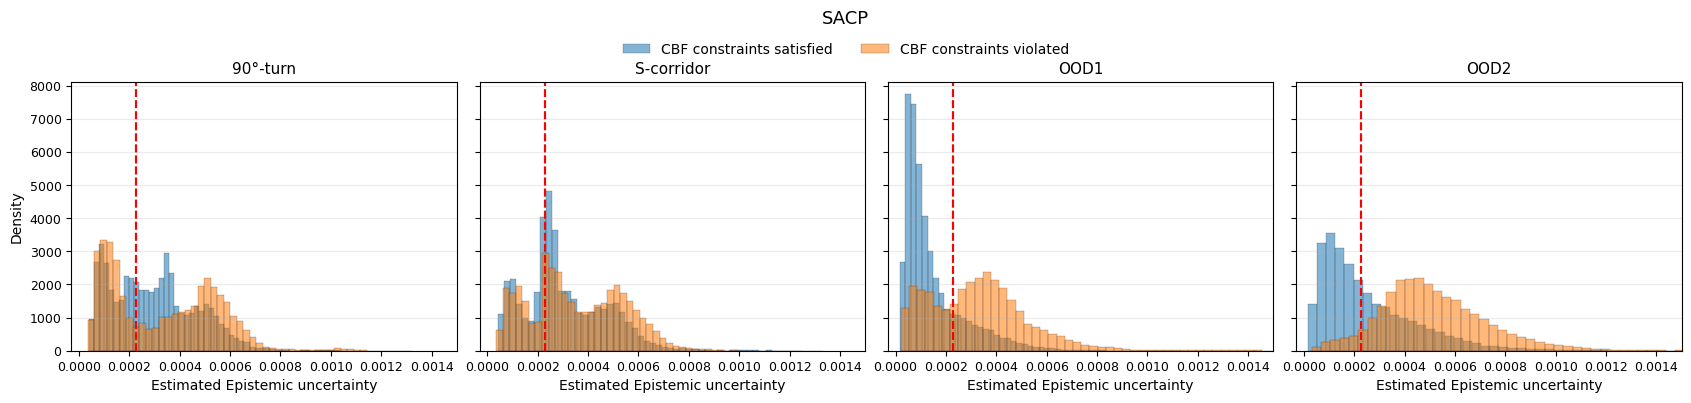

In [8]:
analyze_stats('./results_stats/stats_ext_sac.json', 
    plot=2,
    vertical_line=0.000198,
);
analyze_stats('./results_stats/stats_ext_sacp.json', 
    plot=2,
    vertical_line=0.000228,
);

In [4]:
from uncertainty_utils import *

In [6]:
# SAC, SACP, PPO, PPOP
OOD_1 = ['OOD_UECBF_TH090_2', 'OOD_UECBF_TH090_2', 'UECBF_TH080_PPO', 'UECBF_TH080_PPO'] # d_safe 0.25
OOD_3 = ['OOD_UECBF_TH090_2', 'OOD_UECBF_TH090_2', 'UECBF_TH085_PPO', 'UECBF_TH085_PPO'] # d_safe 0.25

ST_1 = ['ST_UECBF_TH095', 'ST_UECBF_TH095', 'ST_UECBF_TH080_PPO', 'ST_UECBF_TH080_PPO'] # d_safe 0.25
ST_2 = ['ST_UECBF_TH090', 'ST_UECBF_TH090', 'ST_UECBF_TH090_PPO', 'ST_UECBF_TH085_PPO'] # d_safe 0.25

SA = ['SA_UECBF_TH090_2', 'SA_UECBF_TH090_2', 'SA_UECBF_TH085_PPO', 'SA_UECBF_TH085_PPO'] # d_safe 0.2

quantili = [[0.90, 0.90, 0.80, 0.80], [0.90, 0.90, 0.85, 0.85], [0.95, 0.95, 0.80, 0.80], [0.90, 0.90, 0.90, 0.85], [0.90, 0.90, 0.85, 0.85]]
labels = ['OOD_1', 'OOD_3', 'ST_1', 'ST_2', 'SA']
t = [OOD_1, OOD_3, ST_1, ST_2, SA]
t = [[f'./results/{x}.csv' for x in gruppo] for gruppo in t]
lambdas = [ lambda x: x['collisions'] < 80, 
           lambda x: x['collisions'] < 80, 
           
           lambda x: x['collisions'] < 80 and x['global_avg_dist_obstacle'] == 0 and x['length'] > 35, 
           lambda x: x['collisions'] < 80 and x['global_avg_dist_obstacle'] == 2 and x['length'] > 35,
           
           lambda x: x['collisions'] < 80 and x['length'] > 35
           ]
env_names = ['obstacles_ood1', 'obstacles_ood3', None, None, None]

metrics = ['success_nc','collision_rate', 'success', 'collisions', 'reward', 'length', 'velocity', 'distance_traveled', 'stuck_rate', 'vel_success', 'length_success']#  'weighted_success', 'SPL'
simple_metrics = ['success_nc_mean', 'success_nc_std', 'collision_rate_mean', 'collision_rate_std', 'stuck_rate_mean', 'stuck_rate_std',  'length_success_mean', 'length_success_std']

p_names_1 = [
 'NEW_TR_SIMPLE_EASY_5804798',
 'NEW_TR_SIMPLEWP_EASY_5841772',
 ]
p_names_2 = [
 'PPO_RETRAIN_7154081',
 'PPOWP_7167668'
 ]

sac_ue = load_trained_ensemble('./unc_models/' + 'unc_' + 'NEW_TR_SIMPLE_EASY_5804798', (21 + 7)*4 + 2, (21 + 7), 'cuda')[0]
sac_ue_norm = torch.load('./unc_models/' + 'unc_' + 'NEW_TR_SIMPLE_EASY_5804798' + '/norm.pth', map_location='cuda')

sacp_ue = load_trained_ensemble('./unc_models/' + 'unc_' + 'NEW_TR_SIMPLEWP_EASY_5841772', (21 + 7)*4 + 2, (21 + 7), 'cuda')[0]
sacp_ue_norm = torch.load('./unc_models/' + 'unc_' + 'NEW_TR_SIMPLEWP_EASY_5841772' + '/norm.pth', map_location='cuda')

ppo_ue = load_trained_ensemble('./unc_models/' + 'unc_' + 'PPO_RETRAIN_7154081', (21 + 7)*4 + 2, (21 + 7), 'cuda')[0]
ppo_ue_norm = torch.load('./unc_models/' + 'unc_' + 'PPO_RETRAIN_7154081' + '/norm.pth', map_location='cuda')

ppop_ue = load_trained_ensemble('./unc_models/' + 'unc_' + 'PPOWP_7167668', (21 + 7)*4 + 2, (21 + 7), 'cuda')[0]
ppop_ue_norm = torch.load('./unc_models/' + 'unc_' + 'PPOWP_7167668' + '/norm.pth', map_location='cuda')

norms = [sac_ue_norm, sacp_ue_norm, ppo_ue_norm, ppop_ue_norm]

Caricamento di 10 modelli elite...
Caricamento di 10 modelli elite...
Caricamento di 10 modelli elite...
Caricamento di 10 modelli elite...


In [24]:
idc_unc_percentile = int(torch.argmin(torch.abs(norms[0]['percentile_levels'] - 0.9)))
idc_unc_percentile

100

In [40]:
i = 0
idc_unc_percentile = int(torch.argmin(torch.abs(norms[i]['percentile_levels'] - 0.925)))
x = norms[i]['epistemic']['percentiles'][idc_unc_percentile]

print(format(x, ".17g"))

0.00019845739006996155


In [41]:
i = 1
idc_unc_percentile = int(torch.argmin(torch.abs(norms[i]['percentile_levels'] - 0.925)))
x = norms[i]['epistemic']['percentiles'][idc_unc_percentile]

print(format(x, ".17g"))

0.00022840364545118064


In [18]:
real_th = []
for amb in special_th:
    for i, pol in enumerate(special_th[amb]):
        idc_unc_percentile = int(torch.argmin(torch.abs(norms[i]['percentile_levels'] - 0.9)))
        percentile_real_value = norms[i]['epistemic']['percentiles'][idc_unc_percentile]
    
        real_th.append( percentile_real_value )